# Recovering progression constraints with TreeMHN

Runs the real **[TreeMHN](https://github.com/cbg-ethz/TreeMHN)** (Luo, Kuipers & Beerenwinkel 2023) on
a cohort simulated by `iscc`, and checks that it recovers the event-ordering constraints that were
*planted* when the cohort was grown.

**R notebook**, kernel `R (iscc-treemhn)`, no simulation. Generated once by
`python validation/make_analysis_data.py --only treemhn`:

| file | what it is | who sees it |
|---|---|---|
| `trees.csv` | one mutation tree per patient, **reconstructed by SCITE**, in TreeMHN's own `input_tree_df` layout | the tool |
| `truth_network.json` | the planted precedence DAG | **scoring only** |

**The trees are inferred, not read.** `iscc` knows every patient's true tree, and handing that
straight to TreeMHN would make this vacuous — it would be estimating rates from the topology it
is meant to infer. Each patient is genotyped single-cell instead, with dropout and false
positives, and [SCITE reconstructs the tree](tool_scite_trees.ipynb) from that noisy matrix.

**The question.** Real cohort data has no answer key — you cannot tell whether a recovered dependency
is real. Here `iscc` grew every patient under a *known* DAG saying which events must precede which, so
recovery is measurable.

Two details make this a fair test rather than a trivial one, and both were learned the hard way:

- **The constraints are `accessibility`-gated**, meaning they act on the mutation process itself, so
  the ordering genuinely appears in tree topology — the observable TreeMHN reads. (iscc can also gate
  the *same* DAG on fitness, where it changes only how large the carrying clones grow and leaves no
  ordering trace. TreeMHN estimates rates, so it recovers nothing from that — a real finding, but a
  statement about observables rather than about the tool, and it belongs in the benchmark suite.)
- **The event alphabet is common enough for a gated child to occur.** A child cannot appear until its
  parent has, so with rare events it arises in almost no patient and there is nothing in the data to
  find, however good the method.

In [1]:
source("r_preamble.R")
suppressMessages({ library(TreeMHN); library(jsonlite) })

data_dir <- analysis_dir("treemhn")
df    <- read.csv(file.path(data_dir, "trees.csv"))
truth <- fromJSON(file.path(data_dir, "truth_network.json"))

n        <- max(df$Mutation_ID)          # number of real events (the root is 0)
patients <- unique(df$Patient_ID)
dag <- truth$true_dag_edges              # rows: (parent, child), 0-based event ids

cat(sprintf("cohort: %d patients, %d events, %d tree rows\n", length(patients), n, nrow(df)))
cat(sprintf("gating: %s   planted precedence constraints: %d\n",
            truth$dependency_params$gating_mode, nrow(dag)))
for (i in seq_len(nrow(dag)))
  cat(sprintf("   E%d  must precede  E%d\n", dag[i, 1], dag[i, 2]))

               Welcome to the TreeMHN package!

This package is developed by the Computational Biology Group
of ETH Zurich and the Swiss Institute of Bioinformatics (SIB).

Please cite the following paper when using this package:
https://www.nature.com/articles/s41467-023-39400-w

For any questions, please contact niko.beerenwinkel@bsse.ethz.ch



cohort: 36 patients, 4 events, 180 tree rows


gating: accessibility   planted precedence constraints: 2


   E3  must precede  E1
   E0  must precede  E2


## Fit

`input_tree_df` is TreeMHN's own constructor, and `learn_MHN` returns the estimated Θ — a matrix
whose off-diagonal entries are the promoting (positive) or inhibiting (negative) effects of one event
on another's rate.

In [2]:
tree_df <- df[, c("Patient_ID", "Tree_ID", "Node_ID", "Mutation_ID", "Parent_ID")]
tree_obj <- input_tree_df(n = n, tree_df = tree_df,
                          patients = as.character(patients),
                          mutations = paste0("E", seq_len(n) - 1))

Theta <- learn_MHN(tree_obj, gamma = 0.5, verbose = FALSE, return_Theta_only = TRUE)
rownames(Theta) <- colnames(Theta) <- paste0("E", seq_len(n) - 1)
round(Theta, 3)

,E0,E1,E2,E3
E0,-0.103,-2.059,-2.294,-2.134
E1,-0.674,-1.714,-0.694,1.643
E2,0.018,-2.619,-1.007,-0.589
E3,-1.774,-2.815,-1.327,-0.317


## Scoring against the planted constraints

In an MHN, `Theta[i, j]` is the effect of event *j* on event *i*'s rate — positive means *j* promotes
*i*. A planted "*p* must precede *c*" constraint should therefore surface as a **large positive
`Theta[c, p]`**.

So the test is not whether Θ looks plausible, but whether the planted pairs are the *top-ranked*
promoting entries out of all off-diagonals.

In [3]:
off_idx <- which(row(Theta) != col(Theta), arr.ind = TRUE)
off_val <- Theta[off_idx]
ord     <- order(off_val, decreasing = TRUE)

# planted (parent, child) -> the Theta entry that should carry it: Theta[child, parent]
planted <- lapply(seq_len(nrow(dag)), function(i) c(child = dag[i, 2] + 1L, parent = dag[i, 1] + 1L))

cat("TreeMHN vs the planted DAG\n")
ranks <- integer(0)
for (pc in planted) {
  hit <- which(off_idx[ord, "row"] == pc["child"] & off_idx[ord, "col"] == pc["parent"])
  ranks <- c(ranks, hit)
  cat(sprintf("  E%d -> E%d :  Theta = %+.3f   rank %d of %d off-diagonal entries\n",
              pc["parent"] - 1L, pc["child"] - 1L,
              Theta[pc["child"], pc["parent"]], hit, length(off_val)))
}
cat(sprintf("\n  both planted edges in the top %d of %d  ->  %s\n",
            max(ranks), length(off_val),
            ifelse(max(ranks) <= nrow(dag), "RECOVERED (they are the top entries)",
                   ifelse(max(ranks) <= length(off_val) / 3, "recovered (top third)", "not recovered"))))
cat("\nstrongest off-diagonals overall:\n")
top <- head(ord, 4)
for (k in top)
  cat(sprintf("   E%d -> E%d : %+.3f\n", off_idx[k, "col"] - 1L, off_idx[k, "row"] - 1L, off_val[k]))

TreeMHN vs the planted DAG


  E3 -> E1 :  Theta = +1.643   rank 1 of 12 off-diagonal entries
  E0 -> E2 :  Theta = +0.018   rank 2 of 12 off-diagonal entries



  both planted edges in the top 2 of 12  ->  RECOVERED (they are the top entries)



strongest off-diagonals overall:


   E3 -> E1 : +1.643
   E0 -> E2 : +0.018
   E3 -> E2 : -0.589
   E0 -> E1 : -0.674


## The network, drawn by TreeMHN itself

`plot_Theta` and `plot_pathways` are the package's own figures — the same ones in the TreeMHN paper.
`plot_Theta` shows the estimated Θ as a heatmap (diagonal = baseline rates, off-diagonal = one
event's effect on another's rate); `plot_pathways` lists the most probable mutational orders the
fitted model implies.

TableGrob (1 x 2) "arrange": 2 grobs
  z     cells    name           grob
1 1 (1-1,1-1) arrange gtable[layout]
2 2 (1-1,2-2) arrange gtable[layout]

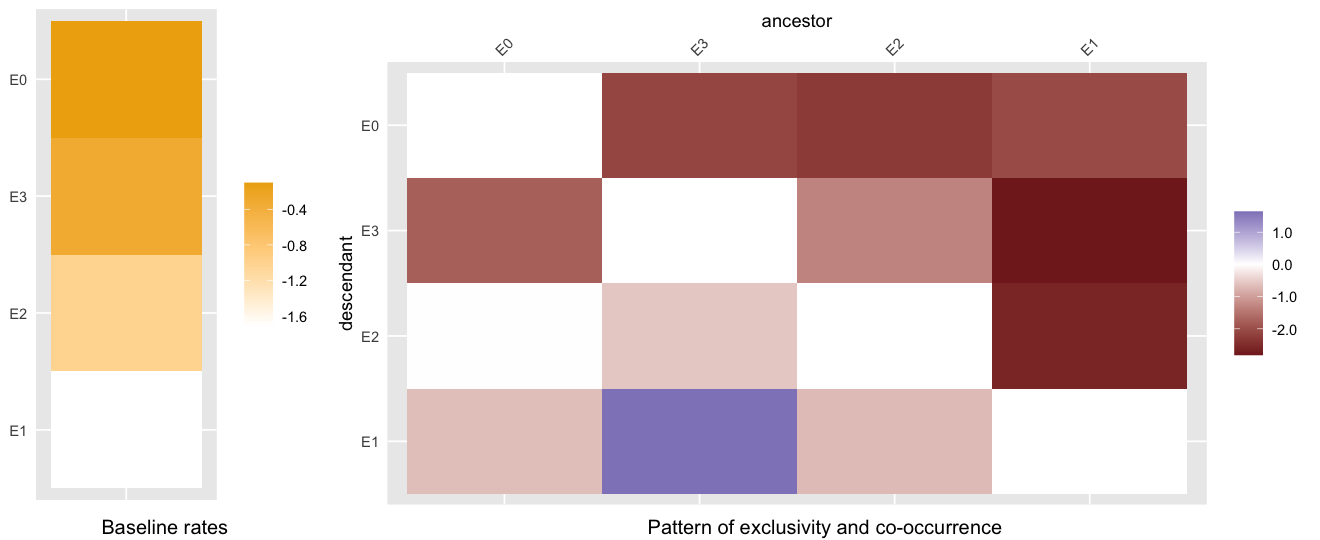

In [4]:
suppressMessages(library(ggplot2))
options(repr.plot.width = 11, repr.plot.height = 4.5)

mut_names <- paste0("E", seq_len(n) - 1)
plot_Theta(Theta, mutations = mut_names, full = TRUE)

The planted constraints were `E3 → E1` and `E0 → E2`. Read those cells in the heatmap above: a
promoting effect of a parent on its child is a positive (red) off-diagonal entry.

Below, the most probable mutational pathways the fitted model implies — a planted precedence should
show up as the parent appearing before its child.

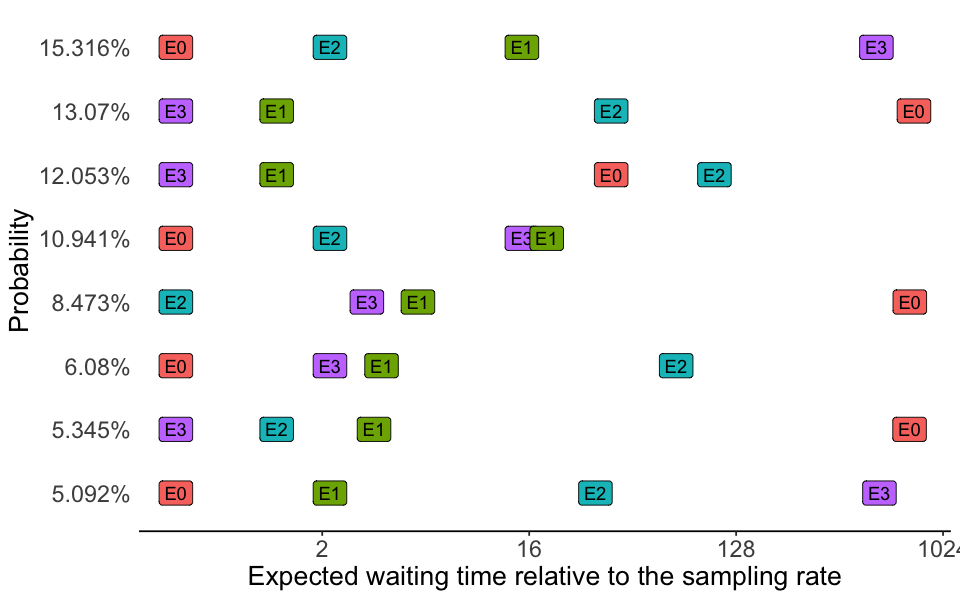

In [5]:
options(repr.plot.width = 8, repr.plot.height = 5)
plot_pathways(Theta, mutations = mut_names, n_order = 4, top_M = 8)

## The contrast: the same cohort read cross-sectionally

TreeMHN reads **mutation trees**, which carry the order in which each patient acquired its events.
Classical **MHN** (Schill et al. 2020) reads only a **binary presence matrix** — "did this patient ever
acquire event *i*" — which is what a cross-sectional or bulk cohort gives you, and which discards order
entirely.

`make_analysis_data.py` writes both views of these same patients, so the comparison isolates what the
extra resolution of trees buys. MHN is a Python package, so it gets its own notebook and its own
kernel rather than being shelled out to from here.